# Allen natural-scene decoding and reconstruction

## Imports and Allen session


In [2]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPRegressor
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score,
    top_k_accuracy_score,
    mean_squared_error,
)
from sklearn.metrics.pairwise import cosine_similarity

from allensdk.brain_observatory.ecephys.ecephys_project_cache import (
    EcephysProjectCache,
)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch:", torch.__version__)
print("Device:", device)


PyTorch: 2.13.0
Device: cpu


In [3]:
cache_dir = Path("./data/allen_cache").resolve()
manifest_path = cache_dir / "manifest.json"

cache = EcephysProjectCache.from_warehouse(
    manifest=str(manifest_path)
)

selected_session_ids = [
    732592105,
    797828357,
    755434585,
    756029989,
    791319847,
]

session_id = selected_session_ids[0]
session = cache.get_session_data(session_id)

stimulus_presentations = session.stimulus_presentations.copy()

print("Loaded session:", session_id)
print("Total stimulus presentations:", len(stimulus_presentations))


/opt/anaconda3/envs/allen-vc/lib/python3.11/site-packages/hdmf/spec/namespace.py:535: UserWarning: Ignoring cached namespace 'hdmf-common' version 1.1.3 because version 1.8.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."
/opt/anaconda3/envs/allen-vc/lib/python3.11/site-packages/hdmf/spec/namespace.py:535: UserWarning: Ignoring cached namespace 'core' version 2.2.2 because version 2.7.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."


Loaded session: 732592105
Total stimulus presentations: 70388


In [ ]:
natural_scenes = stimulus_presentations[
    stimulus_presentations["stimulus_name"] == "natural_scenes"
].copy()

natural_scenes = natural_scenes[
    natural_scenes["frame"] >= 0
].copy()

natural_scenes["frame"] = natural_scenes["frame"].astype(int)

print("Natural-scene trials:", len(natural_scenes))
print("Unique images:", natural_scenes["frame"].nunique())
print("Trials/image (first five):")
print(natural_scenes["frame"].value_counts().sort_index().head())


Natural-scene trials: 5900
Unique images: 118
Trials/image (first five):
0    50
1    50
2    50
3    50
4    50
Name: frame, dtype: int64


In [5]:
target_areas = ["VISp", "VISl", "VISpm"]

units = session.units.copy()

selected_units = units[
    units["ecephys_structure_acronym"].isin(target_areas)
].copy()

print("Selected units:", len(selected_units))
print(selected_units["ecephys_structure_acronym"].value_counts())


Selected units: 216
VISp     110
VISpm     66
VISl      40
Name: ecephys_structure_acronym, dtype: int64


## Neural features


In [205]:
unit_ids = selected_units.index.to_numpy()
presentation_ids = natural_scenes.index.to_numpy()

WINDOW_START = 0.05
WINDOW_END = 0.25

time_bin_edges = np.array([
    WINDOW_START,
    WINDOW_END,
])

spike_counts = session.presentationwise_spike_counts(
    bin_edges=time_bin_edges,
    stimulus_presentation_ids=presentation_ids,
    unit_ids=unit_ids,
)

X = spike_counts.values[:, 0, :]
y = natural_scenes["frame"].to_numpy()

print(
    f"Response window: "
    f"{WINDOW_START * 1000:.0f}–{WINDOW_END * 1000:.0f} ms"
)
print("Spike-count tensor:", spike_counts.shape)
print("X:", X.shape)
print("y:", y.shape)
print("Classes:", len(np.unique(y)))
print("Mean spike count:", X.mean())
print("Fraction zero:", np.mean(X == 0))

Response window: 50–250 ms
Spike-count tensor: (5900, 1, 216)
X: (5900, 216)
y: (5900,)
Classes: 118
Mean spike count: 1.5141517576898933
Fraction zero: 0.5346453232893911


## Split train/test

In [206]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)
print("Train repeats/image:", np.unique(y_train, return_counts=True)[1][:5])
print("Test repeats/image:", np.unique(y_test, return_counts=True)[1][:5])


Training: (4720, 216)
Testing: (1180, 216)
Train repeats/image: [40 40 40 40 40]
Test repeats/image: [10 10 10 10 10]


## Natural-scene classification


In [207]:
classifier = Pipeline([
    ("scaler", StandardScaler()),
    (
        "classifier",
        LogisticRegression(
            solver="lbfgs",
            penalty="l2",
            C=1.0,
            max_iter=3000,
            random_state=RANDOM_STATE,
        ),
    ),
])

classifier.fit(X_train, y_train)

y_pred_class = classifier.predict(X_test)
y_prob_class = classifier.predict_proba(X_test)

top1_accuracy = accuracy_score(y_test, y_pred_class)
top5_accuracy = top_k_accuracy_score(
    y_test,
    y_prob_class,
    k=5,
    labels=classifier.classes_,
)

chance_accuracy = 1 / len(np.unique(y))

print(f"Chance: {chance_accuracy:.4f}")
print(f"Top-1:  {top1_accuracy:.4f}")
print(f"Top-5:  {top5_accuracy:.4f}")


Chance: 0.0085
Top-1:  0.7424
Top-5:  0.8653


## Image targets


In [208]:
image_dir = Path("data/allen_cache/natural_scene_templates")

natural_scene_images = np.stack([
    np.array(
        Image.open(image_dir / f"natural_scene_{frame_id}.tiff")
    )
    for frame_id in range(118)
])

recon_shape = (32, 32)

small_scene_images = np.stack([
    np.array(
        Image.fromarray(image).resize(recon_shape)
    )
    for image in natural_scene_images
]).astype(np.float32)

small_scene_images = (
    small_scene_images - small_scene_images.min()
) / (
    small_scene_images.max() - small_scene_images.min()
)

true_test_images = small_scene_images[y_test]

print("Original templates:", natural_scene_images.shape)
print("32×32 targets:", small_scene_images.shape)
print("Range:", small_scene_images.min(), small_scene_images.max())


Original templates: (118, 918, 1174)
32×32 targets: (118, 32, 32)
Range: 0.0 1.0


## Evaluation helpers

In [209]:
def image_metrics(true_images, predicted_images):
    true_flat = true_images.reshape(len(true_images), -1)
    pred_flat = predicted_images.reshape(len(predicted_images), -1)

    mse = mean_squared_error(true_flat, pred_flat)

    corrs = []
    for true_image, pred_image in zip(true_images, predicted_images):
        corrs.append(
            np.corrcoef(
                true_image.ravel(),
                pred_image.ravel(),
            )[0, 1]
        )

    corrs = np.asarray(corrs)

    return {
        "mse": mse,
        "mean_corr": np.nanmean(corrs),
        "median_corr": np.nanmedian(corrs),
        "correlations": corrs,
    }


def print_image_metrics(name, metrics):
    print(name)
    print(f"  Pixel MSE:          {metrics['mse']:.4f}")
    print(f"  Mean correlation:   {metrics['mean_corr']:.4f}")
    print(f"  Median correlation: {metrics['median_corr']:.4f}")


def latent_dimension_correlations(true_latent, predicted_latent):
    corrs = []
    for dim in range(true_latent.shape[1]):
        corrs.append(
            np.corrcoef(
                true_latent[:, dim],
                predicted_latent[:, dim],
            )[0, 1]
        )
    return np.asarray(corrs)


def show_reconstructions(
    true_images,
    predicted_images,
    labels,
    n_examples=8,
    seed=42,
    predicted_title="Reconstruction",
):
    indices = np.random.default_rng(seed).choice(
        len(labels),
        size=min(n_examples, len(labels)),
        replace=False,
    )

    fig, axes = plt.subplots(
        len(indices),
        2,
        figsize=(7, 3 * len(indices)),
    )

    if len(indices) == 1:
        axes = np.array([axes])

    for row, idx in enumerate(indices):
        axes[row, 0].imshow(
            true_images[idx],
            cmap="gray",
            vmin=0,
            vmax=1,
        )
        axes[row, 0].set_title(f"True frame {int(labels[idx])}")
        axes[row, 0].axis("off")

        axes[row, 1].imshow(
            predicted_images[idx],
            cmap="gray",
            vmin=0,
            vmax=1,
        )
        axes[row, 1].set_title(predicted_title)
        axes[row, 1].axis("off")

    plt.tight_layout()
    plt.show()


## PCA reconstruction baseline

Current selected PCA setting:
- 100 image PCA components
- standardized PCA targets
- MLP (256, 128)


In [210]:
flat_scene_images = small_scene_images.reshape(118, -1)

image_pca = PCA(
    n_components=100,
    random_state=RANDOM_STATE,
)

scene_pca_features = image_pca.fit_transform(flat_scene_images)

Y_train_pca = scene_pca_features[y_train]
Y_test_pca = scene_pca_features[y_test]

print("PCA representation:", scene_pca_features.shape)
print(
    "Explained variance:",
    image_pca.explained_variance_ratio_.sum(),
)


PCA representation: (118, 100)
Explained variance: 0.9879466


In [211]:
pca_target_scaler = StandardScaler()

Y_train_pca_scaled = pca_target_scaler.fit_transform(
    Y_train_pca
)

pca_model = Pipeline([
    ("neural_scaler", StandardScaler()),
    (
        "mlp",
        MLPRegressor(
            hidden_layer_sizes=(256, 128),
            activation="relu",
            solver="adam",
            alpha=1e-3,
            learning_rate_init=1e-3,
            max_iter=500,
            early_stopping=True,
            validation_fraction=0.2,
            n_iter_no_change=20,
            random_state=RANDOM_STATE,
        ),
    ),
])

pca_model.fit(
    X_train,
    Y_train_pca_scaled,
)

Y_pred_pca_scaled = pca_model.predict(X_test)
Y_pred_pca = pca_target_scaler.inverse_transform(
    Y_pred_pca_scaled
)

pca_reconstructions = image_pca.inverse_transform(
    Y_pred_pca
).reshape(-1, 32, 32)


In [212]:
pca_metrics = image_metrics(
    true_test_images,
    pca_reconstructions,
)

pca_component_corrs = latent_dimension_correlations(
    Y_test_pca,
    Y_pred_pca,
)

pca_similarities = cosine_similarity(
    Y_pred_pca,
    scene_pca_features,
)

pca_retrieval = np.mean(
    np.argmax(pca_similarities, axis=1) == y_test
)

print_image_metrics("PCA baseline", pca_metrics)
print(f"  Retrieval accuracy: {pca_retrieval:.4f}")
print(
    f"  Mean component corr: "
    f"{np.nanmean(pca_component_corrs):.4f}"
)
print(
    f"  Median component corr: "
    f"{np.nanmedian(pca_component_corrs):.4f}"
)


PCA baseline
  Pixel MSE:          0.0319
  Mean correlation:   0.6141
  Median correlation: 0.7314
  Retrieval accuracy: 0.6534
  Mean component corr: 0.6408
  Median component corr: 0.6452


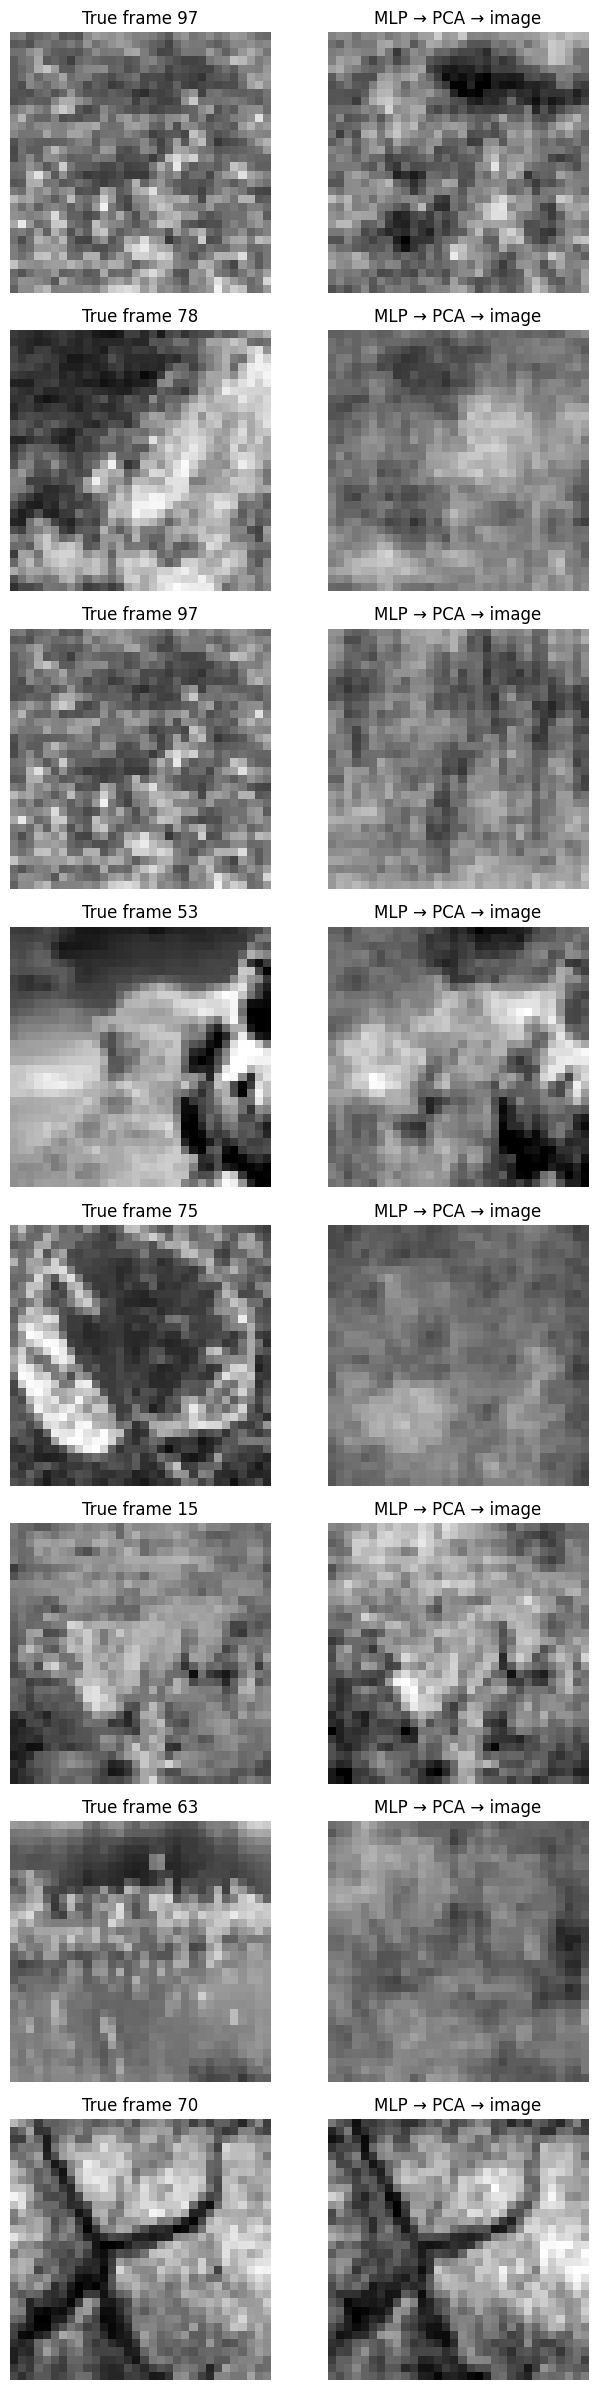

In [213]:
show_reconstructions(
    true_test_images,
    pca_reconstructions,
    y_test,
    predicted_title="MLP → PCA → image",
)


## VAE


In [214]:
vae_images = torch.tensor(
    small_scene_images[:, None, :, :],
    dtype=torch.float32,
)

LATENT_DIM = 32
BETA = 1e-3


class VAE(nn.Module):
    def __init__(self, latent_dim=32):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Flatten(),
        )

        self.fc_mu = nn.Linear(32 * 8 * 8, latent_dim)
        self.fc_logvar = nn.Linear(32 * 8 * 8, latent_dim)

        self.fc_decode = nn.Linear(latent_dim, 32 * 8 * 8)

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(
                32,
                16,
                kernel_size=4,
                stride=2,
                padding=1,
            ),
            nn.ReLU(),
            nn.ConvTranspose2d(
                16,
                1,
                kernel_size=4,
                stride=2,
                padding=1,
            ),
            nn.Sigmoid(),
        )

    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = self.fc_decode(z)
        h = h.view(-1, 32, 8, 8)
        return self.decoder(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        reconstruction = self.decode(z)
        return reconstruction, mu, logvar


def vae_loss(
    reconstructed,
    original,
    mu,
    logvar,
    beta=BETA,
):
    reconstruction_loss = F.mse_loss(
        reconstructed,
        original,
        reduction="mean",
    )

    kl_loss = -0.5 * torch.mean(
        1
        + logvar
        - mu.pow(2)
        - logvar.exp()
    )

    total_loss = (
        reconstruction_loss
        + beta * kl_loss
    )

    return total_loss, reconstruction_loss, kl_loss


vae = VAE(
    latent_dim=LATENT_DIM
).to(device)

print(vae)


VAE(
  (encoder): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Flatten(start_dim=1, end_dim=-1)
  )
  (fc_mu): Linear(in_features=2048, out_features=32, bias=True)
  (fc_logvar): Linear(in_features=2048, out_features=32, bias=True)
  (fc_decode): Linear(in_features=32, out_features=2048, bias=True)
  (decoder): Sequential(
    (0): ConvTranspose2d(32, 16, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(16, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): Sigmoid()
  )
)


In [215]:
vae_loader = DataLoader(
    TensorDataset(vae_images),
    batch_size=16,
    shuffle=True,
)

vae_optimizer = torch.optim.Adam(
    vae.parameters(),
    lr=1e-3,
    weight_decay=1e-5,
)

VAE_EPOCHS = 300

vae_total_history = []
vae_recon_history = []
vae_kl_history = []

for epoch in range(VAE_EPOCHS):
    vae.train()

    total_sum = 0.0
    recon_sum = 0.0
    kl_sum = 0.0

    for (images,) in vae_loader:
        images = images.to(device)

        vae_optimizer.zero_grad()

        reconstructed, mu, logvar = vae(images)

        total_loss, recon_loss, kl_loss = vae_loss(
            reconstructed,
            images,
            mu,
            logvar,
        )

        total_loss.backward()
        vae_optimizer.step()

        total_sum += total_loss.item()
        recon_sum += recon_loss.item()
        kl_sum += kl_loss.item()

    vae_total_history.append(total_sum / len(vae_loader))
    vae_recon_history.append(recon_sum / len(vae_loader))
    vae_kl_history.append(kl_sum / len(vae_loader))

    if epoch == 0 or (epoch + 1) % 25 == 0:
        print(
            f"Epoch {epoch+1:3d} | "
            f"total={vae_total_history[-1]:.5f} | "
            f"recon={vae_recon_history[-1]:.5f} | "
            f"KL={vae_kl_history[-1]:.5f}"
        )


Epoch   1 | total=0.06144 | recon=0.06133 | KL=0.10984
Epoch  25 | total=0.02234 | recon=0.02037 | KL=1.97397
Epoch  50 | total=0.01632 | recon=0.01402 | KL=2.30206
Epoch  75 | total=0.01243 | recon=0.01000 | KL=2.43571
Epoch 100 | total=0.01031 | recon=0.00777 | KL=2.54129
Epoch 125 | total=0.00876 | recon=0.00629 | KL=2.47611
Epoch 150 | total=0.00791 | recon=0.00538 | KL=2.52972
Epoch 175 | total=0.00750 | recon=0.00505 | KL=2.45860
Epoch 200 | total=0.00694 | recon=0.00447 | KL=2.46988
Epoch 225 | total=0.00669 | recon=0.00425 | KL=2.44591
Epoch 250 | total=0.00644 | recon=0.00398 | KL=2.46131
Epoch 275 | total=0.00613 | recon=0.00367 | KL=2.45130
Epoch 300 | total=0.00603 | recon=0.00364 | KL=2.39150


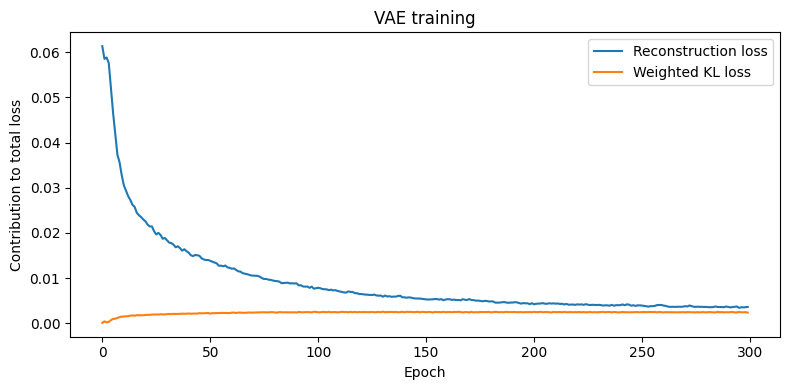

In [216]:
plt.figure(figsize=(8, 4))
plt.plot(
    vae_recon_history,
    label="Reconstruction loss",
)
plt.plot(
    np.asarray(vae_kl_history) * BETA,
    label="Weighted KL loss",
)
plt.xlabel("Epoch")
plt.ylabel("Contribution to total loss")
plt.title("VAE training")
plt.legend()
plt.tight_layout()
plt.show()


In [217]:
vae.eval()

with torch.no_grad():
    all_images = vae_images.to(device)

    scene_vae_latents_tensor, _ = vae.encode(
        all_images
    )

    vae_image_reconstructions_tensor = vae.decode(
        scene_vae_latents_tensor
    )

scene_vae_latents = (
    scene_vae_latents_tensor
    .cpu()
    .numpy()
)

vae_image_reconstructions = (
    vae_image_reconstructions_tensor
    .cpu()
    .numpy()
    [:, 0]
)

vae_only_metrics = image_metrics(
    small_scene_images,
    vae_image_reconstructions,
)

print_image_metrics(
    "Image → VAE → image",
    vae_only_metrics,
)

print("VAE latent shape:", scene_vae_latents.shape)


Image → VAE → image
  Pixel MSE:          0.0030
  Mean correlation:   0.9671
  Median correlation: 0.9726
VAE latent shape: (118, 32)


## Neural → VAE latent baseline

This keeps the previous two-stage idea for comparison:

`spikes → sklearn MLP → VAE latent → frozen VAE decoder → image`

The VAE latent targets are standardized for the regression model.


In [218]:
Y_train_vae = scene_vae_latents[y_train]
Y_test_vae = scene_vae_latents[y_test]

vae_target_scaler = StandardScaler()

Y_train_vae_scaled = vae_target_scaler.fit_transform(
    Y_train_vae
)

vae_neural_model = Pipeline([
    ("neural_scaler", StandardScaler()),
    (
        "mlp",
        MLPRegressor(
            hidden_layer_sizes=(512, 256, 128),
            activation="relu",
            solver="adam",
            alpha=1e-3,
            learning_rate_init=5e-4,
            max_iter=1000,
            early_stopping=True,
            validation_fraction=0.2,
            n_iter_no_change=30,
            random_state=RANDOM_STATE,
        ),
    ),
])

vae_neural_model.fit(
    X_train,
    Y_train_vae_scaled,
)

Y_pred_vae_scaled = vae_neural_model.predict(
    X_test
)

Y_pred_vae = vae_target_scaler.inverse_transform(
    Y_pred_vae_scaled
)

with torch.no_grad():
    neural_vae_reconstructions = vae.decode(
        torch.tensor(
            Y_pred_vae,
            dtype=torch.float32,
            device=device,
        )
    ).cpu().numpy()[:, 0]


In [219]:
vae_neural_metrics = image_metrics(
    true_test_images,
    neural_vae_reconstructions,
)

vae_latent_corrs = latent_dimension_correlations(
    Y_test_vae,
    Y_pred_vae,
)

print_image_metrics(
    "Neural → MLP → VAE → image",
    vae_neural_metrics,
)

print(
    f"  Mean latent corr: "
    f"{np.nanmean(vae_latent_corrs):.4f}"
)
print(
    f"  Median latent corr: "
    f"{np.nanmedian(vae_latent_corrs):.4f}"
)


Neural → MLP → VAE → image
  Pixel MSE:          0.0379
  Mean correlation:   0.5319
  Median correlation: 0.5882
  Mean latent corr: 0.6330
  Median latent corr: 0.6307


## Joint neural encoder: latent loss + image loss

In [220]:
# Freeze VAE parameters.
vae.eval()

for parameter in vae.parameters():
    parameter.requires_grad = False

# Validation split is made only within the original training set.
joint_train_idx, joint_val_idx = train_test_split(
    np.arange(len(X_train)),
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_train,
)

joint_neural_scaler = StandardScaler()
joint_latent_scaler = StandardScaler()

X_joint_train = joint_neural_scaler.fit_transform(
    X_train[joint_train_idx]
)
X_joint_val = joint_neural_scaler.transform(
    X_train[joint_val_idx]
)
X_joint_test = joint_neural_scaler.transform(
    X_test
)

Z_joint_train = joint_latent_scaler.fit_transform(
    Y_train_vae[joint_train_idx]
)
Z_joint_val = joint_latent_scaler.transform(
    Y_train_vae[joint_val_idx]
)

train_images_joint = small_scene_images[
    y_train[joint_train_idx]
]
val_images_joint = small_scene_images[
    y_train[joint_val_idx]
]

joint_train_dataset = TensorDataset(
    torch.tensor(X_joint_train, dtype=torch.float32),
    torch.tensor(Z_joint_train, dtype=torch.float32),
    torch.tensor(train_images_joint[:, None], dtype=torch.float32),
)

joint_val_dataset = TensorDataset(
    torch.tensor(X_joint_val, dtype=torch.float32),
    torch.tensor(Z_joint_val, dtype=torch.float32),
    torch.tensor(val_images_joint[:, None], dtype=torch.float32),
)

joint_train_loader = DataLoader(
    joint_train_dataset,
    batch_size=64,
    shuffle=True,
)

joint_val_loader = DataLoader(
    joint_val_dataset,
    batch_size=128,
    shuffle=False,
)

latent_mean_tensor = torch.tensor(
    joint_latent_scaler.mean_,
    dtype=torch.float32,
    device=device,
)

latent_scale_tensor = torch.tensor(
    joint_latent_scaler.scale_,
    dtype=torch.float32,
    device=device,
)

print("Joint train samples:", len(joint_train_dataset))
print("Joint validation samples:", len(joint_val_dataset))


Joint train samples: 3776
Joint validation samples: 944


In [221]:
class NeuralToLatent(nn.Module):
    def __init__(
        self,
        input_dim,
        latent_dim,
    ):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128, latent_dim),
        )

    def forward(self, x):
        return self.net(x)


joint_neural_encoder = NeuralToLatent(
    input_dim=X_train.shape[1],
    latent_dim=LATENT_DIM,
).to(device)


def unscale_latent_torch(z_scaled):
    return (
        z_scaled * latent_scale_tensor
        + latent_mean_tensor
    )


def decode_scaled_latent(z_scaled):
    z_original = unscale_latent_torch(z_scaled)
    return vae.decode(z_original)


In [222]:
latent_loss_fn = nn.MSELoss()
image_loss_fn = nn.MSELoss()

# Start here. We can tune this only after inspecting loss magnitudes.
LAMBDA_IMAGE = 1.0

joint_optimizer = torch.optim.Adam(
    joint_neural_encoder.parameters(),
    lr=1e-3,
    weight_decay=1e-4,
)

MAX_EPOCHS = 200
PATIENCE = 25

train_total_history = []
train_latent_history = []
train_image_history = []
val_total_history = []

best_val_loss = np.inf
best_state = None
epochs_without_improvement = 0

for epoch in range(MAX_EPOCHS):
    # -----------------------
    # Train
    # -----------------------
    joint_neural_encoder.train()

    train_total = 0.0
    train_latent = 0.0
    train_image = 0.0

    for neural_batch, latent_batch, image_batch in joint_train_loader:
        neural_batch = neural_batch.to(device)
        latent_batch = latent_batch.to(device)
        image_batch = image_batch.to(device)

        joint_optimizer.zero_grad()

        predicted_latent_scaled = joint_neural_encoder(
            neural_batch
        )

        latent_loss = latent_loss_fn(
            predicted_latent_scaled,
            latent_batch,
        )

        predicted_image = decode_scaled_latent(
            predicted_latent_scaled
        )

        image_loss = image_loss_fn(
            predicted_image,
            image_batch,
        )

        total_loss = (
            latent_loss
            + LAMBDA_IMAGE * image_loss
        )

        total_loss.backward()
        joint_optimizer.step()

        train_total += total_loss.item()
        train_latent += latent_loss.item()
        train_image += image_loss.item()

    train_total /= len(joint_train_loader)
    train_latent /= len(joint_train_loader)
    train_image /= len(joint_train_loader)

    train_total_history.append(train_total)
    train_latent_history.append(train_latent)
    train_image_history.append(train_image)

    # -----------------------
    # Validation
    # -----------------------
    joint_neural_encoder.eval()

    val_total = 0.0

    with torch.no_grad():
        for neural_batch, latent_batch, image_batch in joint_val_loader:
            neural_batch = neural_batch.to(device)
            latent_batch = latent_batch.to(device)
            image_batch = image_batch.to(device)

            predicted_latent_scaled = joint_neural_encoder(
                neural_batch
            )

            latent_loss = latent_loss_fn(
                predicted_latent_scaled,
                latent_batch,
            )

            predicted_image = decode_scaled_latent(
                predicted_latent_scaled
            )

            image_loss = image_loss_fn(
                predicted_image,
                image_batch,
            )

            total_loss = (
                latent_loss
                + LAMBDA_IMAGE * image_loss
            )

            val_total += total_loss.item()

    val_total /= len(joint_val_loader)
    val_total_history.append(val_total)

    if val_total < best_val_loss - 1e-5:
        best_val_loss = val_total
        best_state = {
            key: value.detach().cpu().clone()
            for key, value
            in joint_neural_encoder.state_dict().items()
        }
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epoch == 0 or (epoch + 1) % 20 == 0:
        print(
            f"Epoch {epoch+1:3d} | "
            f"train={train_total:.5f} | "
            f"latent={train_latent:.5f} | "
            f"image={train_image:.5f} | "
            f"val={val_total:.5f}"
        )

    if epochs_without_improvement >= PATIENCE:
        print(
            f"Early stopping at epoch {epoch+1}. "
            f"Best validation loss: {best_val_loss:.5f}"
        )
        break

# Restore best validation checkpoint.
joint_neural_encoder.load_state_dict(best_state)
joint_neural_encoder.to(device)
joint_neural_encoder.eval()


Epoch   1 | train=1.00926 | latent=0.95240 | image=0.05687 | val=0.91247
Epoch  20 | train=0.41197 | latent=0.38718 | image=0.02479 | val=0.51009
Epoch  40 | train=0.32855 | latent=0.30818 | image=0.02037 | val=0.48167
Epoch  60 | train=0.28602 | latent=0.26801 | image=0.01801 | val=0.48428
Epoch  80 | train=0.26241 | latent=0.24560 | image=0.01682 | val=0.48174
Epoch 100 | train=0.24931 | latent=0.23319 | image=0.01613 | val=0.47803
Epoch 120 | train=0.23536 | latent=0.22007 | image=0.01529 | val=0.48482
Early stopping at epoch 121. Best validation loss: 0.47522


NeuralToLatent(
  (net): Sequential(
    (0): Linear(in_features=216, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=128, out_features=32, bias=True)
  )
)

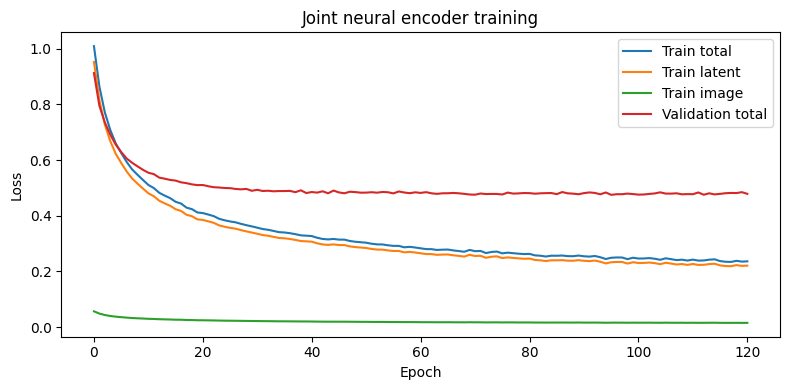

In [223]:
plt.figure(figsize=(8, 4))

plt.plot(
    train_total_history,
    label="Train total",
)
plt.plot(
    train_latent_history,
    label="Train latent",
)
plt.plot(
    train_image_history,
    label="Train image",
)
plt.plot(
    val_total_history,
    label="Validation total",
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Joint neural encoder training")
plt.legend()
plt.tight_layout()
plt.show()


In [224]:
joint_neural_encoder.eval()

X_joint_test_tensor = torch.tensor(
    X_joint_test,
    dtype=torch.float32,
    device=device,
)

with torch.no_grad():
    Y_pred_joint_scaled_tensor = joint_neural_encoder(
        X_joint_test_tensor
    )

    joint_reconstructions_tensor = decode_scaled_latent(
        Y_pred_joint_scaled_tensor
    )

Y_pred_joint_scaled = (
    Y_pred_joint_scaled_tensor
    .cpu()
    .numpy()
)

Y_pred_joint = joint_latent_scaler.inverse_transform(
    Y_pred_joint_scaled
)

joint_reconstructions = (
    joint_reconstructions_tensor
    .cpu()
    .numpy()
    [:, 0]
)

joint_metrics = image_metrics(
    true_test_images,
    joint_reconstructions,
)

joint_latent_corrs = latent_dimension_correlations(
    Y_test_vae,
    Y_pred_joint,
)

print_image_metrics(
    "Joint latent + image-loss model",
    joint_metrics,
)

print(
    f"  Mean latent corr: "
    f"{np.nanmean(joint_latent_corrs):.4f}"
)
print(
    f"  Median latent corr: "
    f"{np.nanmedian(joint_latent_corrs):.4f}"
)


Joint latent + image-loss model
  Pixel MSE:          0.0297
  Mean correlation:   0.6367
  Median correlation: 0.7590
  Mean latent corr: 0.7366
  Median latent corr: 0.7363


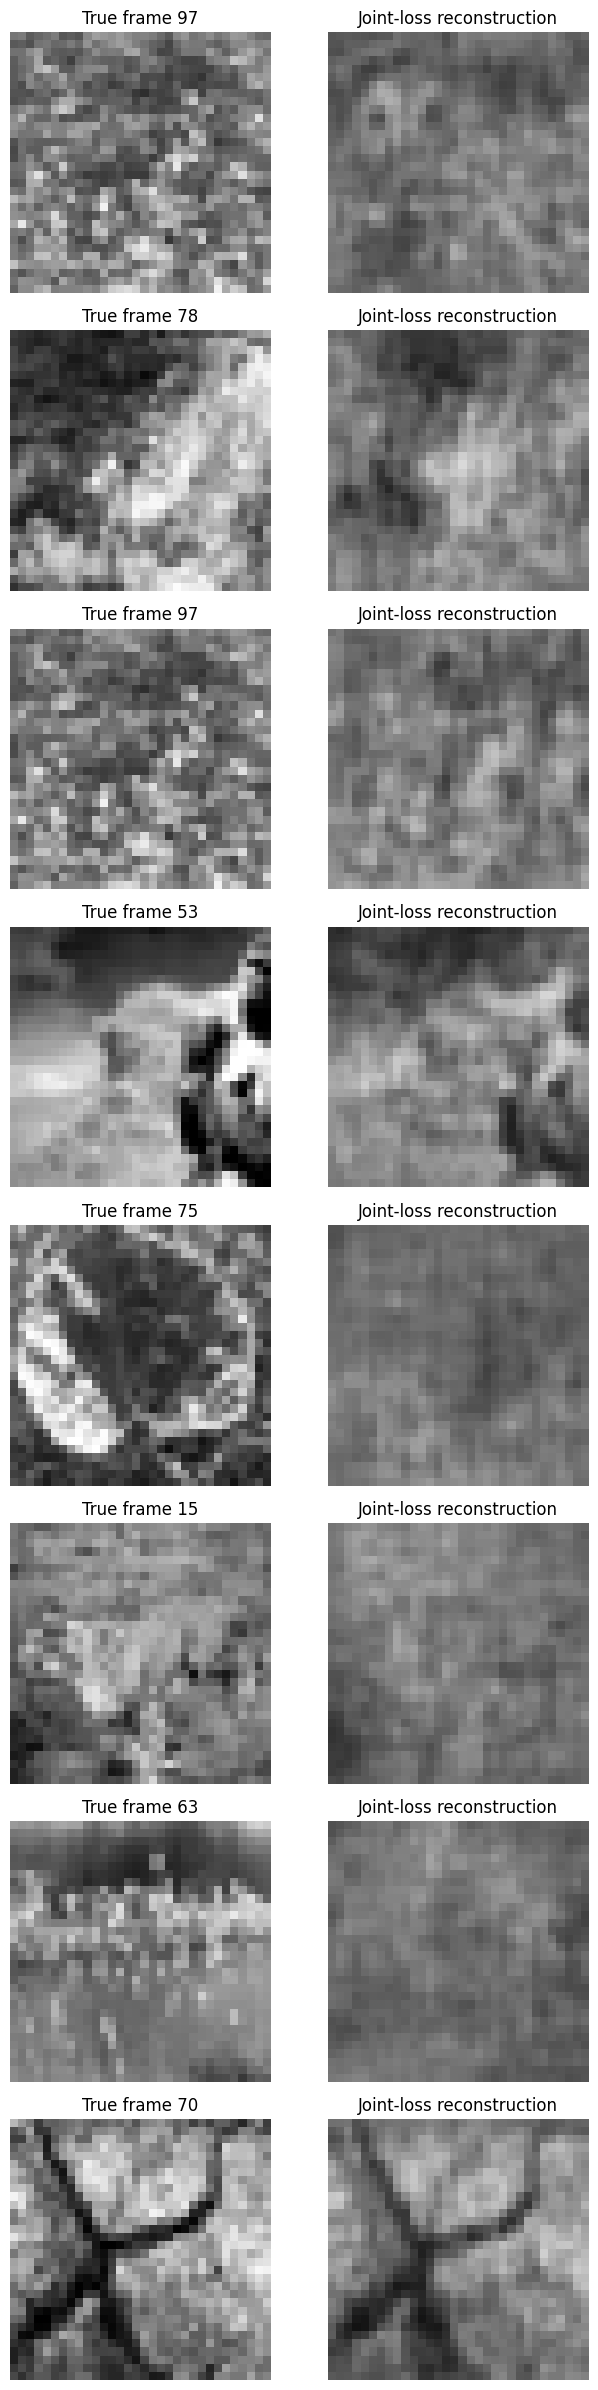

In [225]:
show_reconstructions(
    true_test_images,
    joint_reconstructions,
    y_test,
    predicted_title="Joint-loss reconstruction",
)


## Comparison


In [226]:
comparison_rows = [
    {
        "Model": "PCA100 + MLP",
        "MSE": pca_metrics["mse"],
        "Mean correlation": pca_metrics["mean_corr"],
        "Median correlation": pca_metrics["median_corr"],
        "Mean latent/component correlation": np.nanmean(
            pca_component_corrs
        ),
    },
    {
        "Model": "VAE32 + sklearn MLP",
        "MSE": vae_neural_metrics["mse"],
        "Mean correlation": vae_neural_metrics["mean_corr"],
        "Median correlation": vae_neural_metrics["median_corr"],
        "Mean latent/component correlation": np.nanmean(
            vae_latent_corrs
        ),
    },
    {
        "Model": "VAE32 + joint latent/image loss",
        "MSE": joint_metrics["mse"],
        "Mean correlation": joint_metrics["mean_corr"],
        "Median correlation": joint_metrics["median_corr"],
        "Mean latent/component correlation": np.nanmean(
            joint_latent_corrs
        ),
    },
]

import pandas as pd

comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df)


,Model,MSE,Mean correlation,Median correlation,Mean latent/component correlation
0,PCA100 + MLP,0.031937,0.614087,0.731369,0.640841
1,VAE32 + sklearn MLP,0.037863,0.531873,0.588151,0.632984
2,VAE32 + joint latent/image loss,0.029730,0.636745,0.758962,0.736600


In [227]:
# Four 50-ms bins from 50 to 250 ms
time_bin_edges = np.array([
    0.05,
    0.10,
    0.15,
    0.20,
    0.25,
])

spike_counts_temporal = session.presentationwise_spike_counts(
    bin_edges=time_bin_edges,
    stimulus_presentation_ids=presentation_ids,
    unit_ids=unit_ids,
)

# Expected shape:
# presentations × time_bins × neurons
X_temporal = spike_counts_temporal.values

print("Temporal spike tensor:", X_temporal.shape)

Temporal spike tensor: (5900, 4, 216)


In [228]:
# Use the same trial split as before
train_idx, test_idx = train_test_split(
    np.arange(len(y)),
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

X_temporal_train = X_temporal[train_idx]
X_temporal_test = X_temporal[test_idx]

y_temporal_train = y[train_idx]
y_temporal_test = y[test_idx]

print("X_temporal_train:", X_temporal_train.shape)
print("X_temporal_test:", X_temporal_test.shape)
print("y_temporal_train:", y_temporal_train.shape)
print("y_temporal_test:", y_temporal_test.shape)

X_temporal_train: (4720, 4, 216)
X_temporal_test: (1180, 4, 216)
y_temporal_train: (4720,)
y_temporal_test: (1180,)


In [229]:
# Scale each neuron/bin feature using training data only
n_train, n_bins, n_neurons = X_temporal_train.shape
n_test = X_temporal_test.shape[0]

# Temporarily flatten only for StandardScaler
X_train_flat = X_temporal_train.reshape(n_train, n_bins * n_neurons)
X_test_flat = X_temporal_test.reshape(n_test, n_bins * n_neurons)

temporal_scaler = StandardScaler()

X_train_scaled_flat = temporal_scaler.fit_transform(X_train_flat)
X_test_scaled_flat = temporal_scaler.transform(X_test_flat)

# Restore temporal structure
X_temporal_train_scaled = X_train_scaled_flat.reshape(
    n_train, n_bins, n_neurons
)

X_temporal_test_scaled = X_test_scaled_flat.reshape(
    n_test, n_bins, n_neurons
)

print("Scaled train:", X_temporal_train_scaled.shape)
print("Scaled test:", X_temporal_test_scaled.shape)
print("Train mean:", X_temporal_train_scaled.mean())
print("Train std:", X_temporal_train_scaled.std())

Scaled train: (4720, 4, 216)
Scaled test: (1180, 4, 216)
Train mean: 1.9514277896738471e-19
Train std: 1.0000000000000004


In [230]:
class TemporalNeuralEncoder(nn.Module):
    def __init__(self, n_neurons, latent_dim=32):
        super().__init__()

        # Input shape will be:
        # batch × neurons × time_bins
        self.temporal_conv = nn.Sequential(
            nn.Conv1d(
                in_channels=n_neurons,
                out_channels=128,
                kernel_size=2,
                padding=0,
            ),
            nn.ReLU(),

            nn.Conv1d(
                in_channels=128,
                out_channels=64,
                kernel_size=2,
                padding=0,
            ),
            nn.ReLU(),
        )

        # 4 time bins:
        # after conv1 kernel=2 -> 3 bins
        # after conv2 kernel=2 -> 2 bins
        self.mlp = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 2, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, latent_dim),
        )

    def forward(self, x):
        # Current x:
        # batch × time × neurons
        #
        # Conv1d expects:
        # batch × channels × time
        x = x.permute(0, 2, 1)

        x = self.temporal_conv(x)
        z = self.mlp(x)

        return z


temporal_encoder = TemporalNeuralEncoder(
    n_neurons=n_neurons,
    latent_dim=32,
).to(device)

print(temporal_encoder)

TemporalNeuralEncoder(
  (temporal_conv): Sequential(
    (0): Conv1d(216, 128, kernel_size=(2,), stride=(1,))
    (1): ReLU()
    (2): Conv1d(128, 64, kernel_size=(2,), stride=(1,))
    (3): ReLU()
  )
  (mlp): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=128, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=128, out_features=32, bias=True)
  )
)


In [232]:
# Match temporal trials to the existing VAE latent targets

Y_temporal_train = scene_vae_latents[y_temporal_train]
Y_temporal_test = scene_vae_latents[y_temporal_test]

print("Temporal neural train:", X_temporal_train_scaled.shape)
print("Temporal latent train:", Y_temporal_train.shape)

print("Temporal neural test:", X_temporal_test_scaled.shape)
print("Temporal latent test:", Y_temporal_test.shape)

Temporal neural train: (4720, 4, 216)
Temporal latent train: (4720, 32)
Temporal neural test: (1180, 4, 216)
Temporal latent test: (1180, 32)


In [234]:
# Convert temporal neural data + latent targets to torch tensors

X_temporal_train_tensor = torch.tensor(
    X_temporal_train_scaled,
    dtype=torch.float32
)

X_temporal_test_tensor = torch.tensor(
    X_temporal_test_scaled,
    dtype=torch.float32
)

Y_temporal_train_tensor = torch.tensor(
    Y_temporal_train,
    dtype=torch.float32
)

Y_temporal_test_tensor = torch.tensor(
    Y_temporal_test,
    dtype=torch.float32
)

# Correct image targets for each neural trial
images_temporal_train = torch.tensor(
    small_scene_images[y_temporal_train],
    dtype=torch.float32
).unsqueeze(1)

images_temporal_test = torch.tensor(
    small_scene_images[y_temporal_test],
    dtype=torch.float32
).unsqueeze(1)

print("Neural train:", X_temporal_train_tensor.shape)
print("Latent train:", Y_temporal_train_tensor.shape)
print("Image train:", images_temporal_train.shape)

print("Neural test:", X_temporal_test_tensor.shape)
print("Latent test:", Y_temporal_test_tensor.shape)
print("Image test:", images_temporal_test.shape)

Neural train: torch.Size([4720, 4, 216])
Latent train: torch.Size([4720, 32])
Image train: torch.Size([4720, 1, 32, 32])
Neural test: torch.Size([1180, 4, 216])
Latent test: torch.Size([1180, 32])
Image test: torch.Size([1180, 1, 32, 32])


In [235]:
temporal_joint_train_idx, temporal_joint_val_idx = train_test_split(
    np.arange(len(X_temporal_train_tensor)),
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_temporal_train,
)

# Fit latent scaler ONLY on temporal training subset
temporal_joint_latent_scaler = StandardScaler()

Z_temporal_joint_train = temporal_joint_latent_scaler.fit_transform(
    Y_temporal_train[temporal_joint_train_idx]
)

Z_temporal_joint_val = temporal_joint_latent_scaler.transform(
    Y_temporal_train[temporal_joint_val_idx]
)

Z_temporal_joint_test = temporal_joint_latent_scaler.transform(
    Y_temporal_test
)

# Neural features
X_temporal_joint_train = X_temporal_train_scaled[
    temporal_joint_train_idx
]

X_temporal_joint_val = X_temporal_train_scaled[
    temporal_joint_val_idx
]

X_temporal_joint_test = X_temporal_test_scaled

# Image targets
train_images_temporal_joint = small_scene_images[
    y_temporal_train[temporal_joint_train_idx]
]

val_images_temporal_joint = small_scene_images[
    y_temporal_train[temporal_joint_val_idx]
]

# Build datasets
temporal_joint_train_dataset = TensorDataset(
    torch.tensor(
        X_temporal_joint_train,
        dtype=torch.float32
    ),
    torch.tensor(
        Z_temporal_joint_train,
        dtype=torch.float32
    ),
    torch.tensor(
        train_images_temporal_joint[:, None],
        dtype=torch.float32
    ),
)

temporal_joint_val_dataset = TensorDataset(
    torch.tensor(
        X_temporal_joint_val,
        dtype=torch.float32
    ),
    torch.tensor(
        Z_temporal_joint_val,
        dtype=torch.float32
    ),
    torch.tensor(
        val_images_temporal_joint[:, None],
        dtype=torch.float32
    ),
)

temporal_joint_train_loader = DataLoader(
    temporal_joint_train_dataset,
    batch_size=64,
    shuffle=True,
)

temporal_joint_val_loader = DataLoader(
    temporal_joint_val_dataset,
    batch_size=128,
    shuffle=False,
)

# Needed to differentiably convert standardized latent
# back to original VAE latent space
temporal_latent_mean_tensor = torch.tensor(
    temporal_joint_latent_scaler.mean_,
    dtype=torch.float32,
    device=device,
)

temporal_latent_scale_tensor = torch.tensor(
    temporal_joint_latent_scaler.scale_,
    dtype=torch.float32,
    device=device,
)

print(
    "Temporal joint train:",
    len(temporal_joint_train_dataset)
)

print(
    "Temporal joint validation:",
    len(temporal_joint_val_dataset)
)

print(
    "Train neural shape:",
    X_temporal_joint_train.shape
)

print(
    "Val neural shape:",
    X_temporal_joint_val.shape
)

Temporal joint train: 3776
Temporal joint validation: 944
Train neural shape: (3776, 4, 216)
Val neural shape: (944, 4, 216)


In [236]:
# Re-initialize temporal encoder
temporal_encoder = TemporalNeuralEncoder(
    n_neurons=n_neurons,
    latent_dim=32,
).to(device)

# Freeze VAE parameters
for param in vae.parameters():
    param.requires_grad = False

vae.eval()

optimizer_temporal = torch.optim.Adam(
    temporal_encoder.parameters(),
    lr=1e-3,
    weight_decay=1e-4,
)

criterion_latent = nn.MSELoss()
criterion_image = nn.MSELoss()

LAMBDA_IMAGE = 1.0
MAX_EPOCHS = 200
PATIENCE = 25

best_val_loss = np.inf
best_state = None
patience_counter = 0

temporal_train_losses = []
temporal_val_losses = []

for epoch in range(MAX_EPOCHS):

    # -----------------
    # Training
    # -----------------
    temporal_encoder.train()

    running_train_loss = 0.0

    for xb, zb, img_true in temporal_joint_train_loader:

        xb = xb.to(device)
        zb = zb.to(device)
        img_true = img_true.to(device)

        optimizer_temporal.zero_grad()

        # Predict standardized VAE latent
        z_pred_std = temporal_encoder(xb)

        # Latent loss
        latent_loss = criterion_latent(
            z_pred_std,
            zb
        )

        # Convert standardized prediction back
        # to original VAE latent space
        z_pred = (
            z_pred_std * temporal_latent_scale_tensor
            + temporal_latent_mean_tensor
        )

        # Decode predicted latent
        img_pred = vae.decode(z_pred)

        # Image reconstruction loss
        image_loss = criterion_image(
            img_pred,
            img_true
        )

        loss = (
            latent_loss
            + LAMBDA_IMAGE * image_loss
        )

        loss.backward()
        optimizer_temporal.step()

        running_train_loss += (
            loss.item() * xb.size(0)
        )

    train_loss = (
        running_train_loss
        / len(temporal_joint_train_dataset)
    )

    # -----------------
    # Validation
    # -----------------
    temporal_encoder.eval()

    running_val_loss = 0.0

    with torch.no_grad():

        for xb, zb, img_true in temporal_joint_val_loader:

            xb = xb.to(device)
            zb = zb.to(device)
            img_true = img_true.to(device)

            z_pred_std = temporal_encoder(xb)

            latent_loss = criterion_latent(
                z_pred_std,
                zb
            )

            z_pred = (
                z_pred_std * temporal_latent_scale_tensor
                + temporal_latent_mean_tensor
            )

            img_pred = vae.decode(z_pred)

            image_loss = criterion_image(
                img_pred,
                img_true
            )

            loss = (
                latent_loss
                + LAMBDA_IMAGE * image_loss
            )

            running_val_loss += (
                loss.item() * xb.size(0)
            )

    val_loss = (
        running_val_loss
        / len(temporal_joint_val_dataset)
    )

    temporal_train_losses.append(train_loss)
    temporal_val_losses.append(val_loss)

    # -----------------
    # Early stopping
    # -----------------
    if val_loss < best_val_loss:

        best_val_loss = val_loss

        best_state = {
            k: v.cpu().clone()
            for k, v in temporal_encoder.state_dict().items()
        }

        patience_counter = 0

    else:
        patience_counter += 1

    if (
        epoch == 0
        or (epoch + 1) % 10 == 0
    ):
        print(
            f"Epoch {epoch + 1:3d} | "
            f"train {train_loss:.5f} | "
            f"val {val_loss:.5f}"
        )

    if patience_counter >= PATIENCE:
        print(
            f"Early stopping at epoch {epoch + 1}"
        )
        break


# Restore best model
temporal_encoder.load_state_dict(best_state)
temporal_encoder = temporal_encoder.to(device)

print("Best validation loss:", best_val_loss)

Epoch   1 | train 1.02953 | val 0.95585
Epoch  10 | train 0.43833 | val 0.61718
Epoch  20 | train 0.27706 | val 0.61625
Epoch  30 | train 0.22054 | val 0.62156
Early stopping at epoch 39
Best validation loss: 0.6078048035249872


In [237]:
# -----------------------------
# Evaluate temporal CNN
# -----------------------------

temporal_encoder.eval()
vae.eval()

with torch.no_grad():

    X_test_t = torch.tensor(
        X_temporal_joint_test,
        dtype=torch.float32,
        device=device
    )

    # Predict standardized latent
    z_pred_std = temporal_encoder(X_test_t)

    # Convert back to original VAE latent space
    z_pred = (
        z_pred_std * temporal_latent_scale_tensor
        + temporal_latent_mean_tensor
    )

    # Decode reconstructed images
    temporal_recon = vae.decode(z_pred)

# Move to numpy
temporal_recon_np = (
    temporal_recon
    .cpu()
    .numpy()
    .squeeze(1)
)

z_pred_np = z_pred.cpu().numpy()

# Ground-truth test images
temporal_true_images = small_scene_images[y_temporal_test]

# Ground-truth VAE latent
temporal_true_latents = Y_temporal_test


# -----------------------------
# Pixel MSE
# -----------------------------
temporal_mse = np.mean(
    (temporal_recon_np - temporal_true_images) ** 2
)


# -----------------------------
# Image correlation
# -----------------------------
temporal_corrs = []

for pred, true in zip(
    temporal_recon_np,
    temporal_true_images
):
    corr = np.corrcoef(
        pred.flatten(),
        true.flatten()
    )[0, 1]

    temporal_corrs.append(corr)

temporal_corrs = np.array(temporal_corrs)

temporal_mean_corr = np.nanmean(
    temporal_corrs
)

temporal_median_corr = np.nanmedian(
    temporal_corrs
)


# -----------------------------
# Latent correlation
# -----------------------------
latent_corrs = []

for j in range(z_pred_np.shape[1]):

    corr = np.corrcoef(
        z_pred_np[:, j],
        temporal_true_latents[:, j]
    )[0, 1]

    latent_corrs.append(corr)

latent_corrs = np.array(latent_corrs)

temporal_latent_corr = np.nanmean(
    latent_corrs
)


# -----------------------------
# Print results
# -----------------------------
print("Temporal CNN + Joint VAE")
print("------------------------")
print(f"Pixel MSE:        {temporal_mse:.6f}")
print(f"Mean correlation: {temporal_mean_corr:.6f}")
print(f"Median corr:      {temporal_median_corr:.6f}")
print(f"Latent corr:      {temporal_latent_corr:.6f}")

Temporal CNN + Joint VAE
------------------------
Pixel MSE:        0.036423
Mean correlation: 0.541111
Median corr:      0.600374
Latent corr:      0.641210
